# Scenario risk quantification for "approaching slower vehicle"

In [2]:
# Do the necessary imports
from copy import deepcopy
import os
import numpy as np
from domain_model import DocumentManagement, StateVariable
from simulation import SimulationApproaching, acc_approaching_pars, acc_idm_approaching_pars, accaeb_approaching_pars, \
    IDMPlus, ACC, ACCAEB,  ACCIDMPlus, KDE, kde_from_file
from case_study import get_kpi, case_study, CaseStudy, sample_reactiontime, reactiontime_density

In [2]:
# By default, do not overwrite previous results. Set to True to rerun all simulations.
OVERWRITE = False

## Several simulations

Below, two simulations are performed. One in which the ego vehicle is controlled by the ACC, and one in which the human (modelled using IDM+) can take over. Note the difference in the acceleration after around 5 seconds: this is the point where the human takes over control.

array([0.89368123])

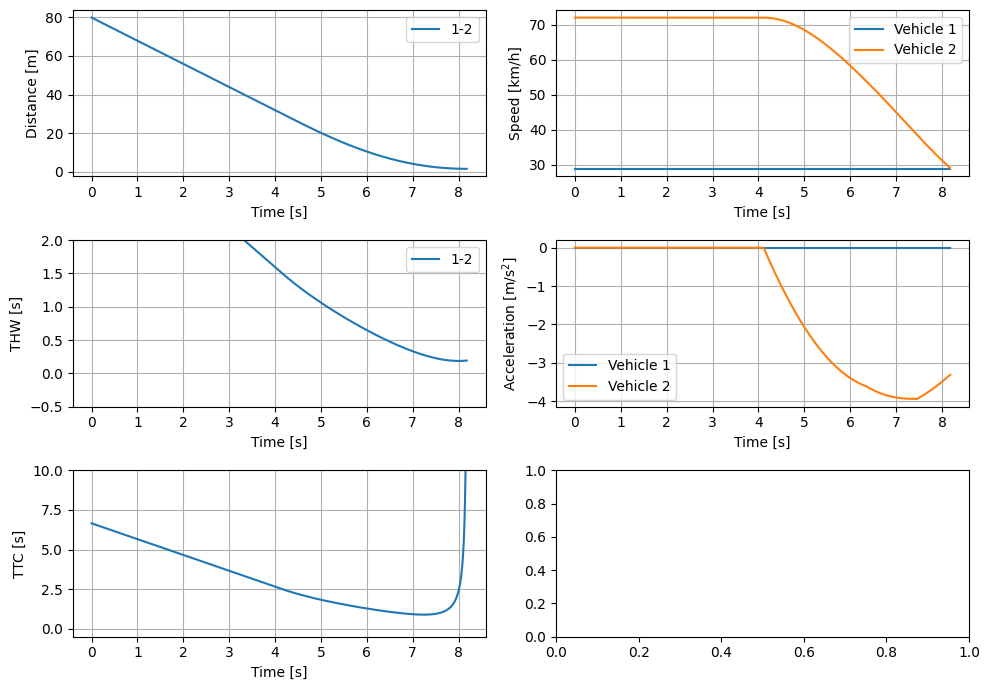

In [8]:
simulator_acc = SimulationApproaching(followers=[ACC()], followers_parameters=[acc_approaching_pars],
                                      min_simulation_time=5)
simulator_acc.simulation(dict(vego=20, ratio_vtar_vego=0.4), plot=True)

array([0.99976078])

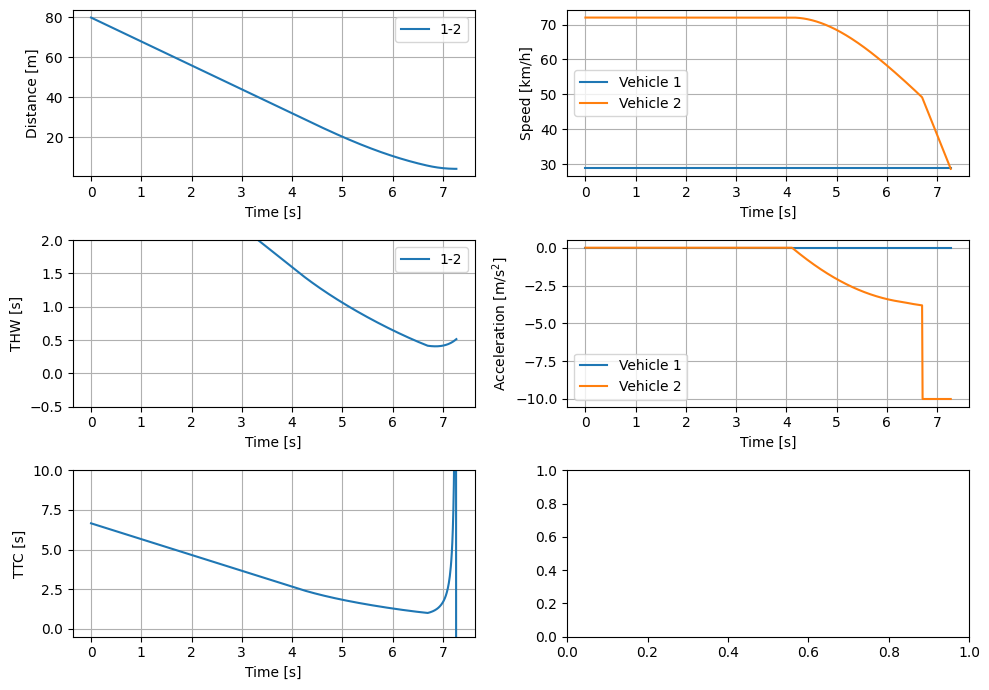

In [7]:
simulator_accaeb = SimulationApproaching(followers=[ACCAEB()], followers_parameters=[accaeb_approaching_pars],
                                      min_simulation_time=5)
simulator_accaeb.simulation(dict(vego=20, ratio_vtar_vego=0.4), plot=True)

array([1.80726921])

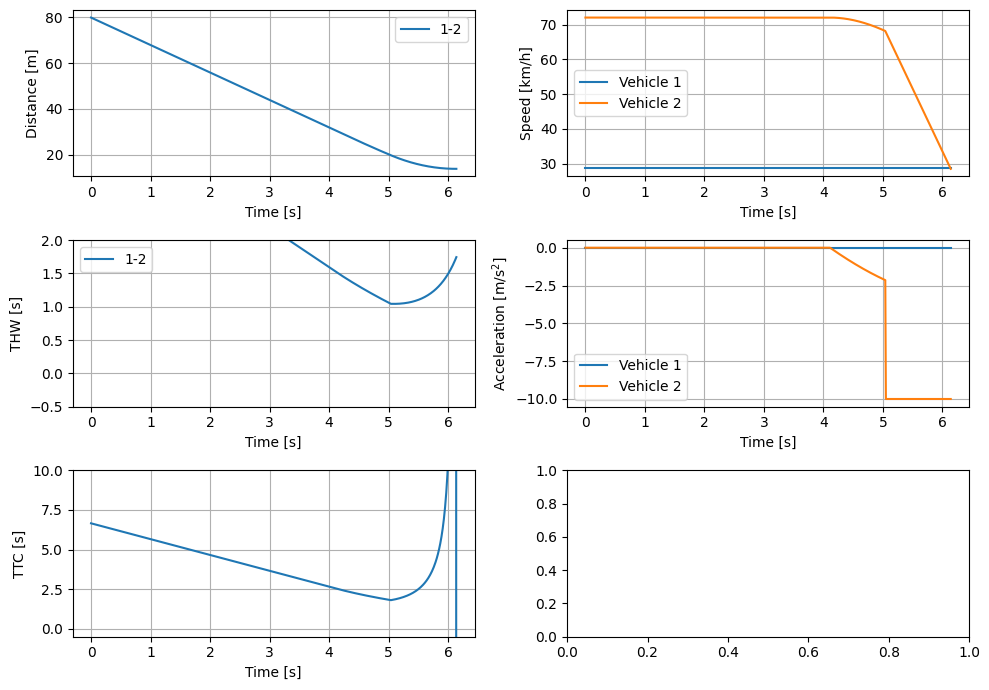

In [6]:
simulator_accidm = SimulationApproaching(followers=[ACCIDMPlus()], 
                                         followers_parameters=[acc_idm_approaching_pars],
                                         min_simulation_time=5)
simulator_accidm.simulation(dict(vego=20, ratio_vtar_vego=0.4, reactiontime=1), plot=True)

Let's now limit the deceleration of the ego vehicle. The minimum distance/TTC becomes a bit lower.

In [ ]:
simulator_accidm.simulation(dict(vego=20, ratio_vtar_vego=0.4, reactiontime=1, amin=-4), plot=True)

Let's limit the viewing range of the ego vehicle. Note that the driver now takes over at about 5.5 seconds into the simulation instead of 5 seconds.

In [ ]:
simulator_accidm.simulation(dict(vego=20, ratio_vtar_vego=0.4, reactiontime=1, max_view=25), plot=True)

## Create KDE of scenario parameters

In [3]:
# Load the data with the scenarios.
scenarios = DocumentManagement(os.path.join("data", "scenarios", "approaching_vehicle.json"))
print("Number of approaching slower vehicle scenarios: {:d}"
      .format(len(scenarios.collections["scenario"])))

Number of approaching slower vehicle scenarios: 291


In [10]:
filename = os.path.join("data", "kde", "approaching_slower_vehicle.p")
if os.path.exists(filename) and not OVERWRITE:
    kde = kde_from_file(filename)
else:
    pars = []
    for key in scenarios.collections["scenario"]:
        scenario = scenarios.get_item("scenario", key)
        vego = scenario.get_state(scenario.get_actor_by_name("ego vehicle"), StateVariable.SPEED,
                                  scenario.get_tstart())
        vtarget = scenario.get_state(scenario.get_actor_by_name("target vehicle"),
                                     StateVariable.LON_TARGET, scenario.get_tstart())[0]
        pars.append([vego, vtarget/vego])

    kde = KDE(np.array(pars))
    kde.compute_bandwidth()
    kde.pickle(filename)

## Perform the case study

#### Some functions that are needed

In [ ]:
# Function that checks if the scenario parameters are valid.
def check_pars(pars):
    if pars[0] <= 0 or pars[1] < 0 or pars[1] >= 1:  # vego>0, 0<=ratio_vtar_vego<1
        return False
    if len(pars) > 2 and pars[2] <= 0:
        return False
    return True

# Function for sampling the parameters in case the ACC model is used.
def func_sample_acc():
    return kde.sample()[0]

# Function for sampling the parameters in case the ACCIDMPlus model is used.
def func_sample_accidmplus():
    return np.concatenate((kde.sample()[0], [sample_reactiontime()]))

# Function for obtaining the pdf of the parameters in case the ACC model is used.
def func_density_acc(pars):
    return kde.score_samples(pars)

# Function for obtaining the pdf of the parameters in case the ACCIDMPlus model is used.
def func_density_accidm(pars):
    return kde.score_samples(pars[:, :2]) * reactiontime_density(pars[:, 2])

#### With ACC, no triggering condition

In [12]:
default_parameters = dict(n=10000,
                          default_parameters=dict(amin=-6),
                          percentile=2,
                          func_validity_check=check_pars,
                          func_process_result=get_kpi)

In [13]:
pars_acc = dict(name="approaching_slower_acc",
                parameters=["vego", "ratio_vtar_vego"],
                simulator=simulator_acc,
                func_sample=func_sample_acc,
                func_density=func_density_acc)
pars_acc.update(default_parameters)
df_mc, df_is = case_study(CaseStudy(**pars_acc), overwrite=OVERWRITE)

Monte Carlo:
  Probability of collision: 8.40e-03 +/- 9.13e-04
  Probability of injury:    1.96e-05 +/- 2.25e-06
Importance sampling:
  Probability of collision: 9.23e-03 +/- 1.33e-04
  Probability of injury:    2.12e-05 +/- 3.20e-07


In [ ]:
#### With ACC & AEB, no triggering condition

In [14]:
pars_accaeb = dict(name="approaching_slower_acc",
                parameters=["vego", "ratio_vtar_vego"],
                simulator=simulator_accaeb,
                func_sample=func_sample_acc,
                func_density=func_density_acc)
pars_accaeb.update(default_parameters)
df_mc, df_is = case_study(CaseStudy(**pars_accaeb), overwrite=OVERWRITE)

Monte Carlo:
  Probability of collision: 8.40e-03 +/- 9.13e-04
  Probability of injury:    1.96e-05 +/- 2.25e-06
Importance sampling:
  Probability of collision: 9.23e-03 +/- 1.33e-04
  Probability of injury:    2.12e-05 +/- 3.20e-07


#### With ACC & IDM+, no triggering condition

In [15]:
pars_accidm = dict(name="approaching_slower_accidm",
                   parameters=["vego", "ratio_vtar_vego", "reactiontime"],
                   simulator=simulator_accidm,
                   func_sample=func_sample_accidmplus,
                   func_density=func_density_accidm)
pars_accidm.update(default_parameters)
df_mc, df_is = case_study(CaseStudy(**pars_accidm), overwrite=OVERWRITE)

Monte Carlo:
  Probability of collision: 0.00e+00 +/- 0.00e+00
  Probability of injury:    0.00e+00 +/- 0.00e+00
Importance sampling:
  Probability of collision: 1.03e-07 +/- 1.02e-07
  Probability of injury:    1.66e-10 +/- 1.64e-10


#### With ACC, triggering condition: low $\mu$

In [ ]:
AMIN = -3  # Corresponding to mu=0.3

In [ ]:
pars = deepcopy(pars_acc)
pars["default_parameters"].update(dict(amin=AMIN))
pars["name"] = "lowmu_approaching_slower_acc"
df_mc, df_is = case_study(CaseStudy(**pars), overwrite=OVERWRITE)

#### With ACC & IDM+, triggering condition: low $\mu$

In [ ]:
pars = deepcopy(pars_accidm)
pars["default_parameters"].update(dict(amin=AMIN))
pars["name"] = "lowmu_approaching_slower_accidm"
df_mc, df_is = case_study(CaseStudy(**pars), overwrite=OVERWRITE)

#### With ACC, triggering condition: low visibility

Result is exactly the same as without this triggering condition, so no need to redo the simulations

In [ ]:
MAX_VIEW = 60  # [m]

In [ ]:
df_mc, df_is = case_study(CaseStudy(**pars_acc), overwrite=False)

#### With ACC & IDM+, triggering condition: low visibility

In [ ]:
pars = deepcopy(pars_accidm)
pars["default_parameters"].update(dict(max_view=MAX_VIEW))
pars["name"] = "late_approaching_slower_accidm"
df_mc, df_is = case_study(CaseStudy(**pars), overwrite=OVERWRITE)